# Demo of Bayesian Experimental Design (BED) in Marketing Mix Modeling (MMM)

In [1]:
import arviz as az
import numpy as np
import plotly.express as px
from bedmmm.data.generator import DataGenerator
from bedmmm.experiment_designer import ExperimentDesigner
from bedmmm.model import MarketingMixModel

## Generate MMM Synthetic Data

There are three components in a MMM synthetic dataset:
- Baseline
- Control variables (in this case, only seasonality)
- Media data

In this section, we will discuss briefly how each component is generated for a timeseries of $T$ weeks.

### Baseline
Baseline is just generated as a single value (plus some white noise if necessary) used across the whole timeseries, independent of how other components are generated in the dataset.

### Seasonality
Seasonality is generated as a sinusoidal wave (this is how Google people typically do it) as follows:
$$
    \cos{\left( \frac{2 \pi (t - 12)}{52}\right)}
$$
where $t = 1, 2, \cdots, T$.

### Media data
Media data in this case is seen as the spends only, as the spends are the easiest metric to control in an experiment. The spends are generated with some correlations with the seasonality (again, the same way as Google people did):
$$
    x_{t, m} = \mu_{m} + \rho_{m} \sqrt{1 - \rho_{m}^2} v_{t, m}
$$
where:
- $\mu_{m} \sim \text{Uniform}(0, 1)$: the base spend of the channel $m$.
- $\rho_{m} \sim \text{Uniform}(0.0, 0.8)$: the correlation factor with the seasonality.
- $v_{t,m} \sim \mathcal{N}(0, 1)$: the white noise.

### Target Values (y)
There are two typical functions used in MMM to model carryover effects and diminishing returns. For carryover effects, we use adstock function:
$$
    \text{adstock}(x_{t, m}^*, r_m, L) = \frac{\sum_{l=0}^{L-1} r_m^l s_{t-l}}{\sum_{l=0}^{L-1} r_m^l}
$$
where:
- $x_{t, m}^* = \{x_{t', m} | t' \leq t \}$: is the spends timeseries up until the time index $t$.
- $r_m$: is the retention rate of the channel $m$.
- $L$: the maximum look-back periods, default to 13 (weeks).

For diminishing returns, we use our Sellforte's exponential function:
$$
    \text{Sellforte}(x_{t, m}; \alpha_m, \beta_m) = \alpha_m \left( 1 - \exp \left(\frac{-x_{t, m}}{\beta_m}\right)\right)
$$
where:
- $\alpha_m$: is the saturation of the channel $m$.
- $\beta_m$: is the shape of the channel $m$.

The target values $y$ are calculated based on the observation model in the Marketing Mix Model (MMM):
$$
    y_t = \sum_{m=1}^M \text{Sellforte}(\text{adstock}(x_{t, m}^*, r_m, L); \alpha_m, \beta_m) + \text{base}_t + \sum_{c=1}^C \gamma_c z_{t, c} + \epsilon_t
$$
where:
- $\gamma_c$: is the control effect of the $c$ control variable.
- $\epsilon_t$: is the added noise.

In [ ]:
generator = (
    DataGenerator(n_time_periods=104, random_seed=10)
    .generate_baseline(
        base=10,
        noise=0.0,
    )
    # Seasonality generated using sine wave
    .generate_control(
        control_effect=1,
        noise=1,
    )
    # 1. Low retention rate, high saturation, high shape
    .generate_media(
        retention_rate=0.2,
        saturation=5,
        shape=3,
        noise=0.0,
    )
    # 2. Low retention rate, low saturation, low shape
    .generate_media(
        retention_rate=0.2,
        saturation=2,
        shape=1,
        noise=0.0,
    )
    # 3. High retention rate, high saturation, high shape
    .generate_media(
        retention_rate=0.8,
        saturation=6,
        shape=3.5,
        noise=0.0,
    )
    # 4. High retention rate, low saturation, low shape
    .generate_media(
        retention_rate=0.8,
        saturation=2,
        shape=1,
        noise=0.0,
    )
    .generate_target(noise=5.0)
)

data = generator.collect()
media_param_df, control_param_df = generator.get_parameters()

In [3]:
figure = px.line(
    data.with_row_index("time_index"),
    x="time_index",
    y=data.columns,
)
figure.show()

## Fit a Marketing Mix Model (MMM)

Fit a MMM model with the same observation model (or response function) as mentioned above with the following priors:
- $r_m \sim \text{Uniform}(lb, ub)$
- $\beta_m \sim \text{HalfNormal}(\sigma_{\beta}^2)$. **NOTE**: I would like to use inverse-gamma distribution for this guy (as Mikko once suggested).
- $\alpha_m \sim \mathcal{N}(\mu_{\alpha, m}, \sigma^2_{\alpha, m})$
- $\gamma_c \sim \mathcal{N}(0, \sigma^2_{\gamma, c})$

And the observation distribution is assumed to be a Normal distribution with scale 5.

In [4]:
model = MarketingMixModel(
    model_config={
        #
        # Media channel 0 priors
        "retention_rate_lb_0": 0.1,
        "retention_rate_ub_0": 0.5,
        "shape_sigma_0": 8,
        "saturation_mu_0": 5,
        "saturation_sigma_0": 1,
        #
        # Media channel 1 priors
        "retention_rate_lb_1": 0.1,
        "retention_rate_ub_1": 0.5,
        "shape_sigma_1": 4,
        "saturation_mu_1": 3,
        "saturation_sigma_1": 1,
        #
        # Media channel 2 priors
        "retention_rate_lb_2": 0.5,
        "retention_rate_ub_2": 0.9,
        "shape_sigma_2": 8,
        "saturation_mu_2": 5,
        "saturation_sigma_2": 1,
        #
        # Media channel 3 priors
        "retention_rate_lb_3": 0.5,
        "retention_rate_ub_3": 0.9,
        "shape_sigma_3": 4,
        "saturation_mu_3": 3,
        "saturation_sigma_3": 1,
        #
        # Control
        "gamma_sigma_0": 1.0,
        #
        # Observation noise
        "obs_sigma": 5,
    }
)

In [ ]:
idata = model.fit(
    data.drop(["y"]).to_pandas(),
    data["y"].to_pandas(),
    random_seed=42,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [retention_rates, shapes, saturations, gammas, baseline]


Output()

Sampling 4 chains for 1_500 tune and 3_000 draw iterations (6_000 + 12_000 draws total) took 31 seconds.
Sampling: [baseline, gammas, retention_rates, saturations, shapes, y]
Sampling: [y]


Output()

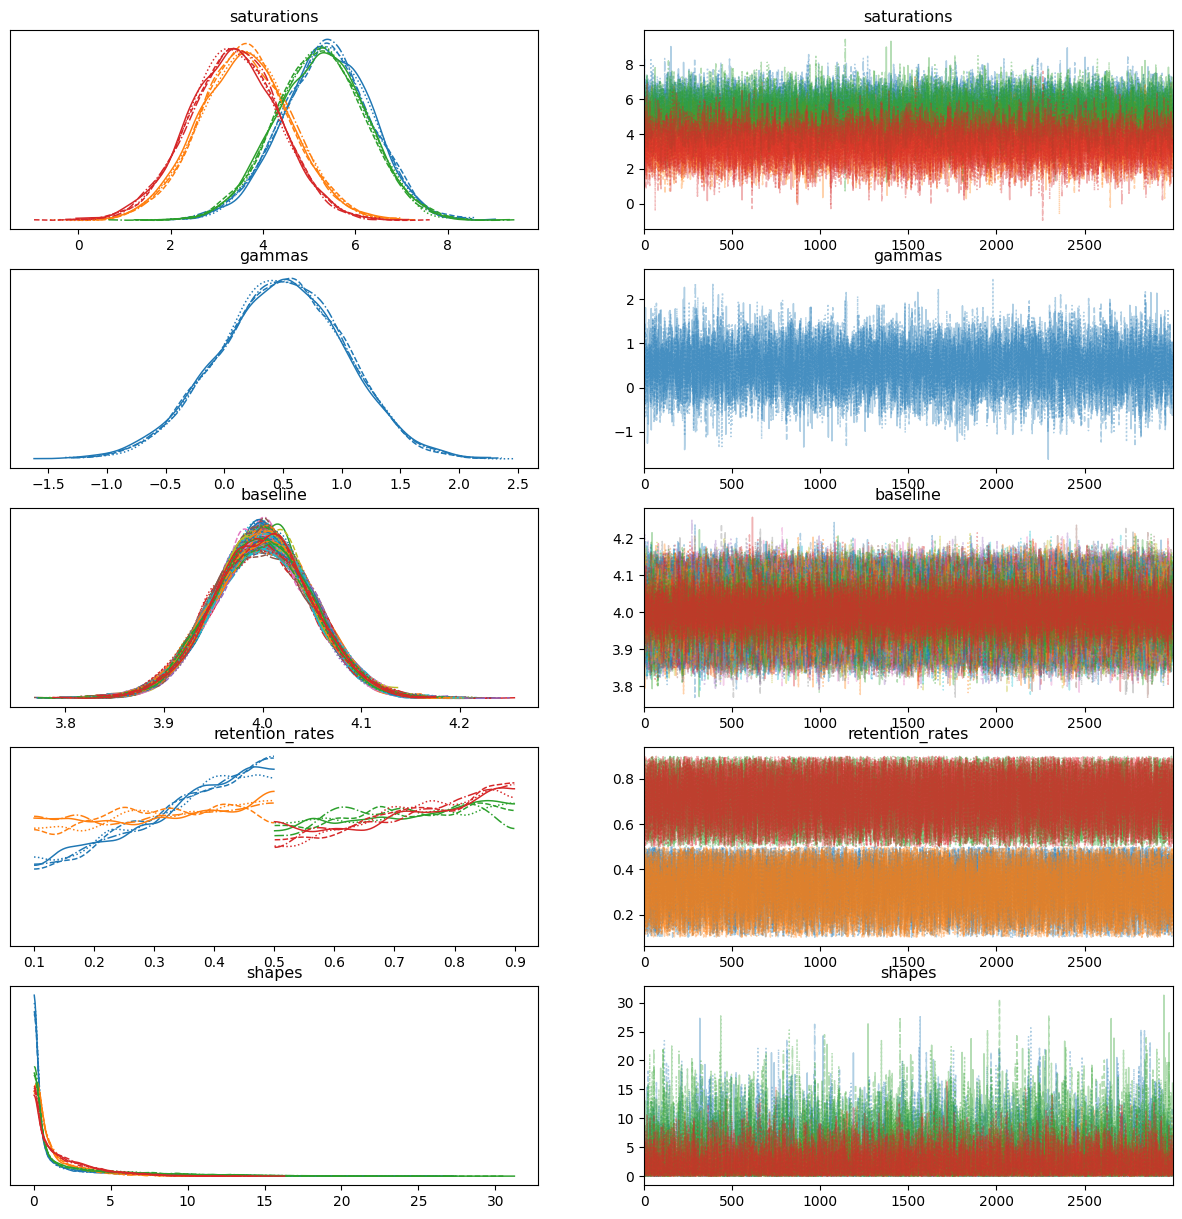

In [6]:
summary_df = az.summary(idata)
az.plot_trace(idata, figsize=(15, 15));

## Find the optimal experiment

The optimal experiment maximizes a specified utility function. The most common utility function is the expected information gain (EIG), which is essentially the KL divergence between the prior and posterior distributions:
$$
    \text{EIG}(d) = \mathbb{E}_{\theta| y, d} \mathbb{E}_{y | d} \left[\log{\frac{p(\theta | y, d)}{p(\theta)}} \right] = \mathbb{E}_{\theta| y, d} \mathbb{E}_{y | d} \left[\log{\frac{p(y, \theta | d)}{p(\theta) p(y | d)}} \right] = \mathbb{E}_{\theta| y, d} \mathbb{E}_{y | d} \left[\log{\frac{p(y| \theta, d)}{ p(y | d)}} \right]
$$

However, in order to carry out one experiment, marketers need to consider the costs of running it. Hence, we would like to add a cost term to the utility function along with the EIG. We call this version of utility function the regularized expected information gain (REIG):
$$
    \text{REIG}(d) = \text{EIG}(d) - (\mathbb{E}(y | \theta, d) - \mathbb{E}(y | \theta, d_0)) - (\text{Cost}(d) - \text{Cost}(d_0))
$$
where $d_0$ is the usual marketing investment activity (when no experiments are carried out). The regularized term takes into account the cost of running the experiments along with the expected sales generated from the experiment.

To estimate the EIG, we implement the Nested Monte Carlo (NMC) method:
$$
    \hat{\mu}_{NMC}(d) = \frac{1}{N} \sum_{n=1}^N \log \frac{p(y_n | \theta_{n, 0}, d)}{\frac{1}{M} \sum_{m=1}^M p(y_n | \theta_{n, m}, d)}
$$
where $\theta_{n, m} \sim p(\theta)$ and $y_n \sim p(y | \theta = \theta_{n, 0}, d)$.

**NOTE**: Let's note that $p(\theta)$ is actually the distribution we get from our fitted MMM model above. Hence, we can use directly the "posterior" samples drawn when fitting the MMM model for the distribution $p(\theta)$ used in the NMC method above.


In [ ]:
desginer = (
    ExperimentDesigner(
        n_media_channels=4,
        n_control_variables=1,
        regularized=False,  # Not yet implemented for regularized utility function
    )
    .add_posterior_samples(idata)
    .configure_experiment_space(
        lower_bound=np.zeros(4),
        upper_bound=np.ones(4) * 5,
    )
)

In [11]:
d_hat = desginer.find_optimal_experiment()

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -0.0772776679897662
        x: [ 5.000e+00  0.000e+00  5.000e+00  1.245e+00]
      nit: 10
      jac: [-1.127e-03  8.445e-03 -1.946e-03  1.961e-06]
     nfev: 60
     njev: 12
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>


In [12]:
d_hat

array([5.        , 0.        , 5.        , 1.24541178])

## Finetune the MMM model with the Experiment

Next steps: use the experiment above to fit/finetune the MMM model again.